# IEEE-CIS Fraud Detection -- Exploratory Data Analysis
**DSC 148 Final Project**  
Dataset: 590,540 transactions . 434 features after identity join . 3.50% fraud rate

In [1]:
#!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
SEED = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Merge

In [2]:
def reduce_mem(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    return df

train_trans = reduce_mem(pd.read_csv('data/train_transaction.csv'))
train_id    = reduce_mem(pd.read_csv('data/train_identity.csv'))
df = train_trans.merge(train_id, on='TransactionID', how='left')

print(f'Transaction table : {train_trans.shape}')
print(f'Identity table    : {train_id.shape}')
print(f'Merged            : {df.shape}')
pct = train_id.TransactionID.nunique() / len(train_trans) * 100
print(f'Transactions with identity : {train_id.TransactionID.nunique():,} / {len(train_trans):,} ({pct:.1f}%)')

Transaction table : (590540, 394)
Identity table    : (144233, 41)
Merged            : (590540, 434)
Transactions with identity : 144,233 / 590,540 (24.4%)


In [ ]:
# Temporal features used in EDA
START_DATE = pd.Timestamp('2017-11-30')
dt = START_DATE + pd.to_timedelta(df['TransactionDT'], unit='s')
df['tx_hour']  = dt.dt.hour.astype('int8')
df['tx_dow']   = dt.dt.dayofweek.astype('int8')
df['tx_month'] = dt.dt.month.astype('int8')
df['card_age'] = (df['TransactionDT'] // 86400 - df['D1']).astype('float32')
print('Temporal features added.')

Temporal features added.


## 2. Exploratory Data Analysis
### 2.1 Basic Statistics

In [4]:
print(f'Total transactions : {len(df):,}')
print(f'Features           : {df.shape[1] - 2}  (excl. TransactionID, isFraud)')
print(f'Fraudulent         : {df.isFraud.sum():,}  ({df.isFraud.mean()*100:.2f}%)')
print(f'Legitimate         : {(df.isFraud==0).sum():,}  ({(1-df.isFraud.mean())*100:.2f}%)')
print()
print('TransactionAmt summary:')
df['TransactionAmt'].describe().round(2)

Total transactions : 590,540
Features           : 436  (excl. TransactionID, isFraud)
Fraudulent         : 20,663  (3.50%)
Legitimate         : 569,877  (96.50%)

TransactionAmt summary:


count    590540.00
mean        135.03
std         239.16
min           0.25
25%          43.32
50%          68.77
75%         125.00
max       31937.39
Name: TransactionAmt, dtype: float64

### 2.2 Class Imbalance

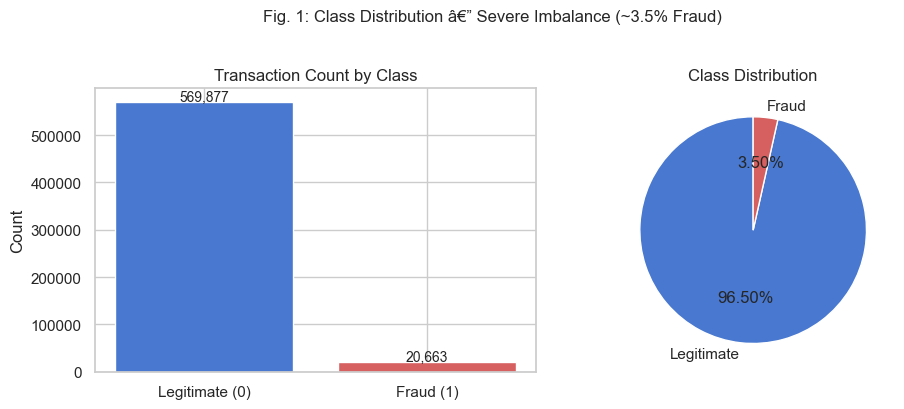

The heavily imbalanced target motivates using AUC-ROC and F1 over raw accuracy.


In [5]:
counts = df['isFraud'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#4878CF', '#D65F5F'], edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Count by Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontsize=10)
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#4878CF', '#D65F5F'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution')
plt.suptitle('Fig. 1: Class Distribution -- Severe Imbalance (~3.5% Fraud)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('The heavily imbalanced target motivates using AUC-ROC and F1 over raw accuracy.')

### 2.3 Missing Value Analysis

Columns with any missing : 415
Columns with >50% missing: 214
Columns with >90% missing: 12


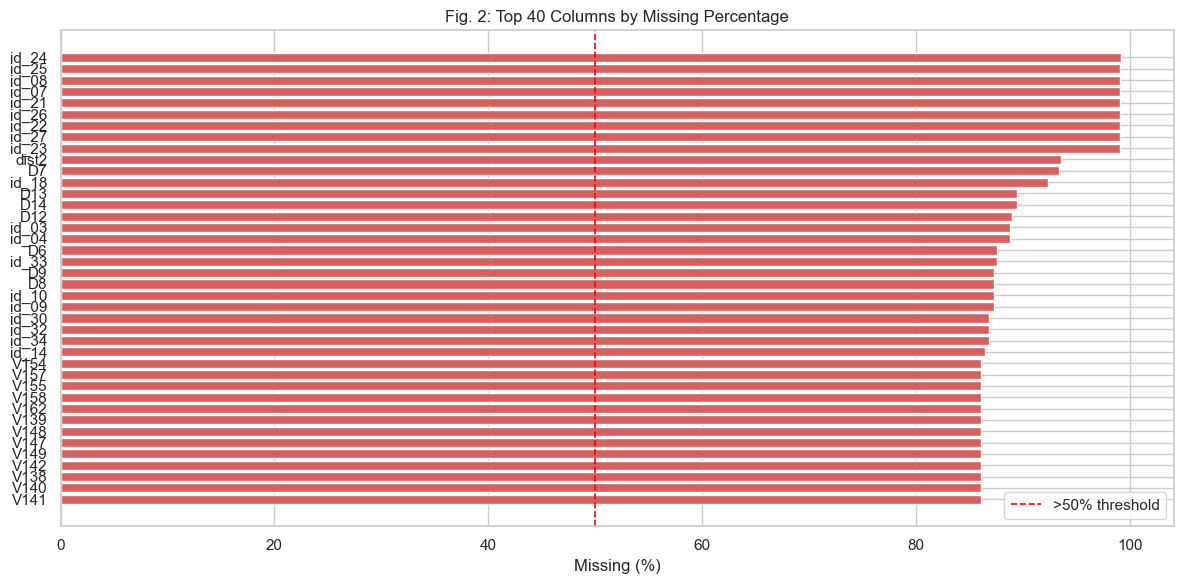

V-features dominate the high-missingness group.
LightGBM handles NaN natively; LR and NB require imputation.


In [6]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print(f'Columns with any missing : {len(miss_pct)}')
print(f'Columns with >50% missing: {(miss_pct > 50).sum()}')
print(f'Columns with >90% missing: {(miss_pct > 90).sum()}')

top40  = miss_pct.head(40)
colors = ['#D65F5F' if v > 50 else '#F0A202' if v > 20 else '#4878CF' for v in top40.values]
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top40.index[::-1], top40.values[::-1], color=colors[::-1])
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='>50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Fig. 2: Top 40 Columns by Missing Percentage')
ax.legend()
plt.tight_layout()
plt.show()
print('V-features dominate the high-missingness group.')
print('LightGBM handles NaN natively; LR and NB require imputation.')

### 2.4 Transaction Amount Distribution

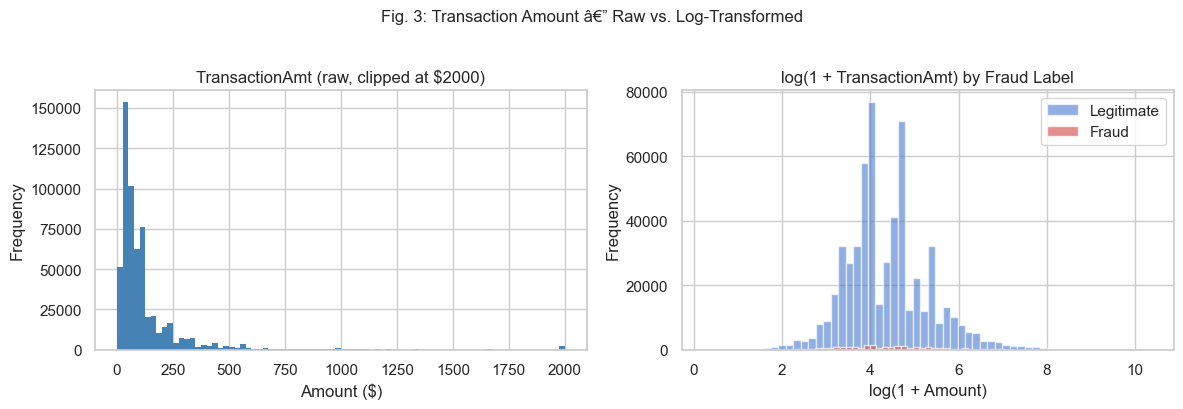

Median Legitimate : $68.50
Median Fraud      : $75.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['TransactionAmt'].clip(upper=2000), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('TransactionAmt (raw, clipped at $2000)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
log_amt = np.log1p(df['TransactionAmt'])
axes[1].hist(log_amt[df.isFraud == 0], bins=60, alpha=0.6, label='Legitimate', color='#4878CF')
axes[1].hist(log_amt[df.isFraud == 1], bins=60, alpha=0.7, label='Fraud',      color='#D65F5F')
axes[1].set_title('log(1 + TransactionAmt) by Fraud Label')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.suptitle('Fig. 3: Transaction Amount -- Raw vs. Log-Transformed', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print(f'Median Legitimate : ${df[df.isFraud==0]["TransactionAmt"].median():.2f}')
print(f'Median Fraud      : ${df[df.isFraud==1]["TransactionAmt"].median():.2f}')

### 2.5 Fraud Rate by Product Category and Card Type

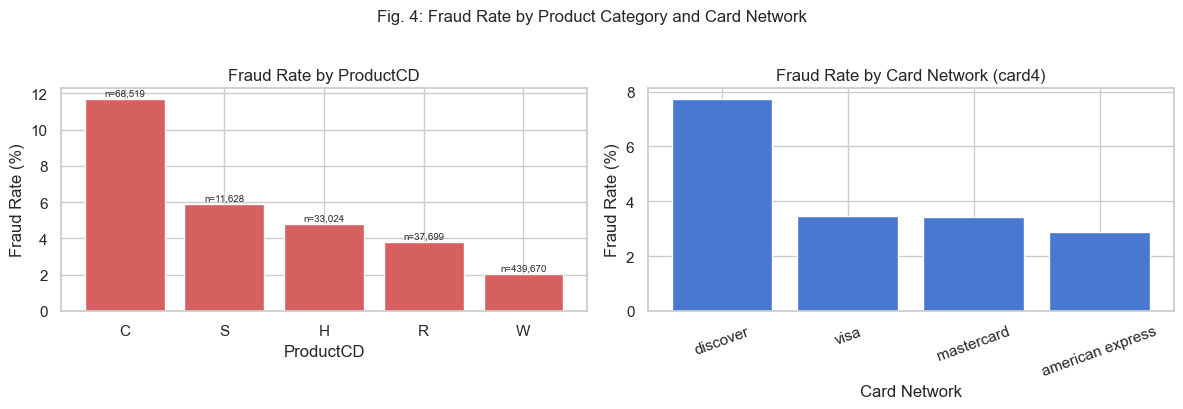

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
prod = (df.groupby('ProductCD').agg(count=('isFraud','count'), fraud_rate=('isFraud','mean'))
          .reset_index().sort_values('fraud_rate', ascending=False))
axes[0].bar(prod['ProductCD'], prod['fraud_rate']*100, color='#D65F5F', edgecolor='white')
for i, row in enumerate(prod.itertuples()):
    axes[0].text(i, row.fraud_rate*100+0.2, f'n={row.count:,}', ha='center', fontsize=7)
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
card4 = (df.groupby('card4').agg(count=('isFraud','count'), fraud_rate=('isFraud','mean'))
           .reset_index().query('count > 200').sort_values('fraud_rate', ascending=False))
axes[1].bar(card4['card4'], card4['fraud_rate']*100, color='#4878CF', edgecolor='white')
axes[1].set_title('Fraud Rate by Card Network (card4)')
axes[1].set_xlabel('Card Network')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Fig. 4: Fraud Rate by Product Category and Card Network', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 2.6 Fraud Rate by Email Domain

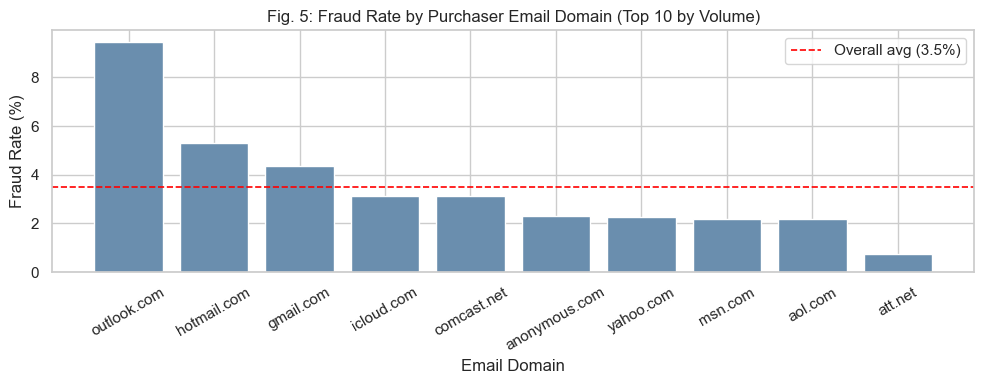

In [9]:
top_domains = df['P_emaildomain'].value_counts().head(10).index
email = (df[df['P_emaildomain'].isin(top_domains)]
           .groupby('P_emaildomain')
           .agg(count=('isFraud','count'), fraud_rate=('isFraud','mean'))
           .reset_index().sort_values('fraud_rate', ascending=False))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(email['P_emaildomain'], email['fraud_rate']*100, color='#6A8EAE', edgecolor='white')
avg_line = df['isFraud'].mean()*100
ax.axhline(avg_line, color='red', linestyle='--', linewidth=1.2, label=f'Overall avg ({avg_line:.1f}%)')
ax.set_title('Fig. 5: Fraud Rate by Purchaser Email Domain (Top 10 by Volume)')
ax.set_xlabel('Email Domain')
ax.set_ylabel('Fraud Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

### 2.7 Temporal Pattern of Fraud

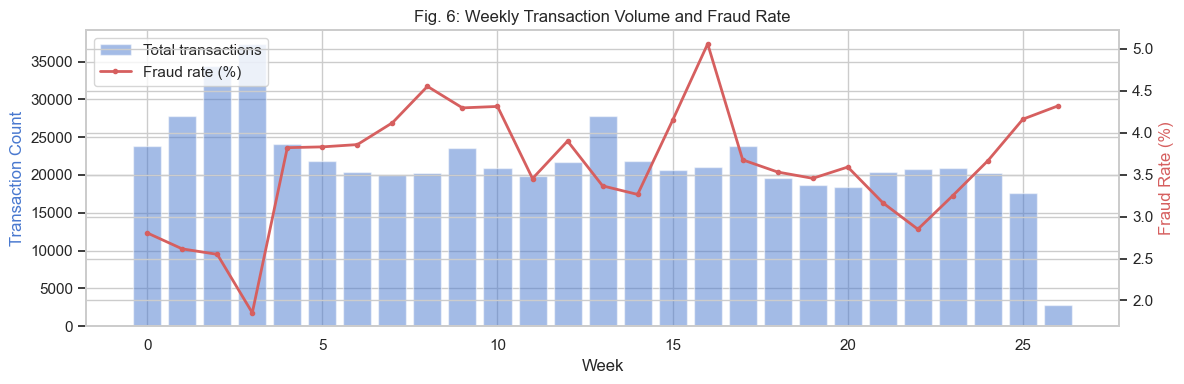

Dataset spans approximately 26 weeks.


In [10]:
df['week'] = (df['TransactionDT'] // (7*24*3600)).astype(int)
weekly = df.groupby('week').agg(total=('isFraud','count'), fraud_rate=('isFraud','mean')).reset_index()
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(weekly['week'], weekly['total'], color='#4878CF', alpha=0.5, label='Total transactions')
ax2.plot(weekly['week'], weekly['fraud_rate']*100, color='#D65F5F',
         linewidth=2, marker='o', markersize=3, label='Fraud rate (%)')
ax1.set_xlabel('Week')
ax1.set_ylabel('Transaction Count', color='#4878CF')
ax2.set_ylabel('Fraud Rate (%)', color='#D65F5F')
ax1.set_title('Fig. 6: Weekly Transaction Volume and Fraud Rate')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()
print(f'Dataset spans approximately {weekly.week.max()} weeks.')
df.drop(columns=['week'], inplace=True)

### 2.8 Count Features (C1--C14) by Fraud Label

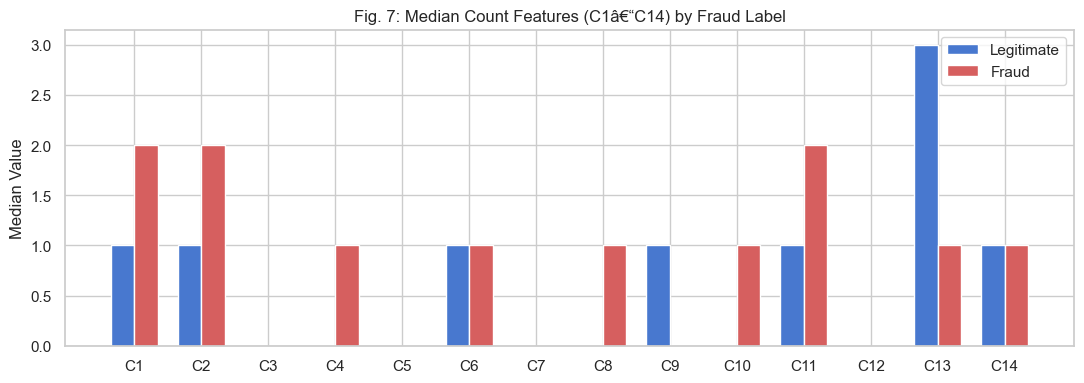

C-features count entity interactions (cards, addresses, devices per transaction).


In [11]:
c_cols = [f'C{i}' for i in range(1,15)]
c_med  = df.groupby('isFraud')[c_cols].median().T
c_med.columns = ['Legitimate', 'Fraud']
x = np.arange(len(c_cols))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x-w/2, c_med['Legitimate'], w, label='Legitimate', color='#4878CF')
ax.bar(x+w/2, c_med['Fraud'],      w, label='Fraud',      color='#D65F5F')
ax.set_xticks(x)
ax.set_xticklabels(c_cols)
ax.set_title('Fig. 7: Median Count Features (C1--C14) by Fraud Label')
ax.set_ylabel('Median Value')
ax.legend()
plt.tight_layout()
plt.show()
print('C-features count entity interactions (cards, addresses, devices per transaction).')

### 2.9 Correlation Heatmap

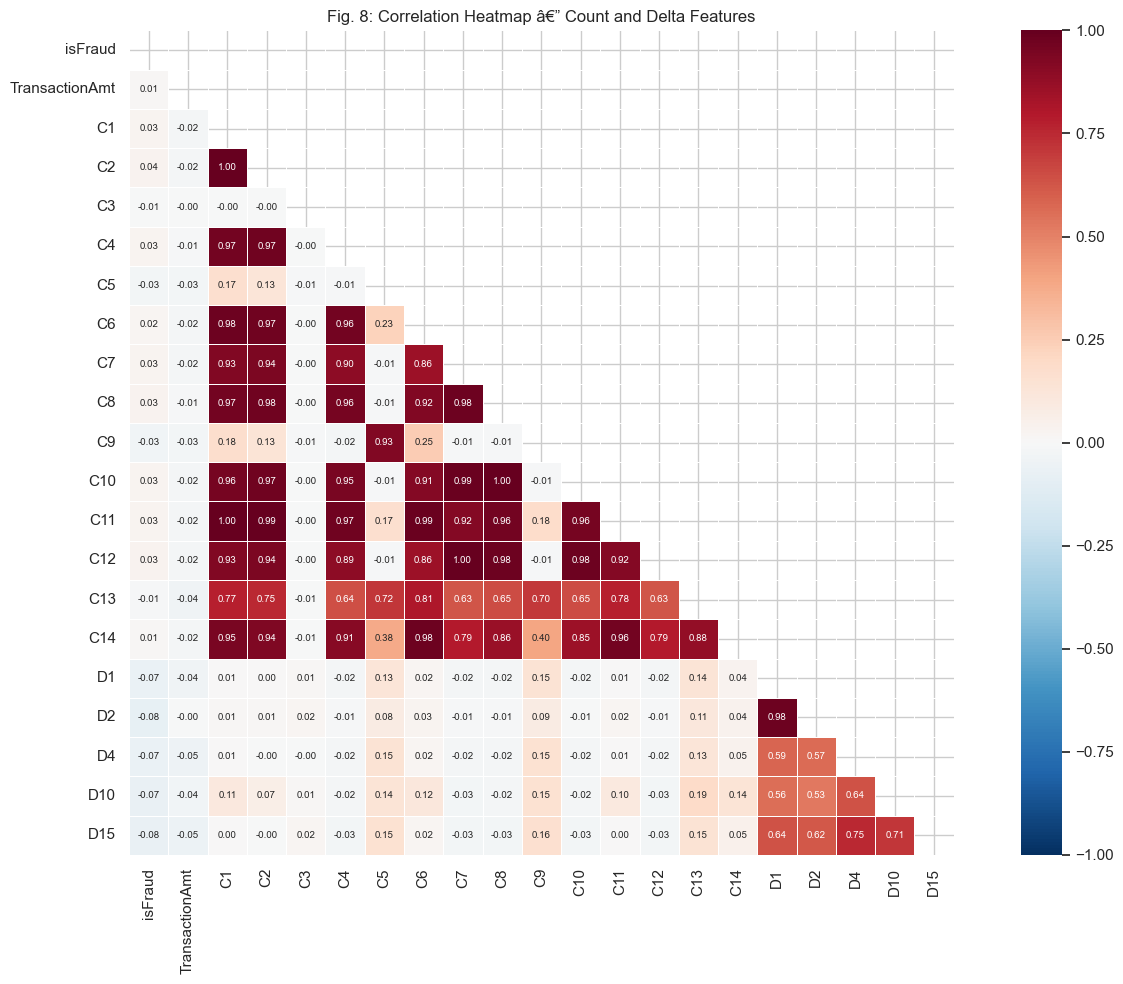

In [12]:
heat_cols = ['isFraud','TransactionAmt'] + c_cols + ['D1','D2','D4','D10','D15']
heat_cols = [c for c in heat_cols if c in df.columns]
corr = df[heat_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=0.4,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Fig. 8: Correlation Heatmap -- Count and Delta Features', fontsize=12)
plt.tight_layout()
plt.show()

### 2.10 Adversarial Validation

Train a classifier to distinguish early vs. late transactions (label 0 vs. 1).  
High AUC confirms the client population -- not just fraud patterns -- shifts over time (1st-place insight).  
5th-place finding: features with high adversarial AUC can still improve OOF AUC; do not discard on adversarial grounds alone.

Adversarial validation AUC: 0.9987
AUC > 0.5 confirms client population shifts over time.


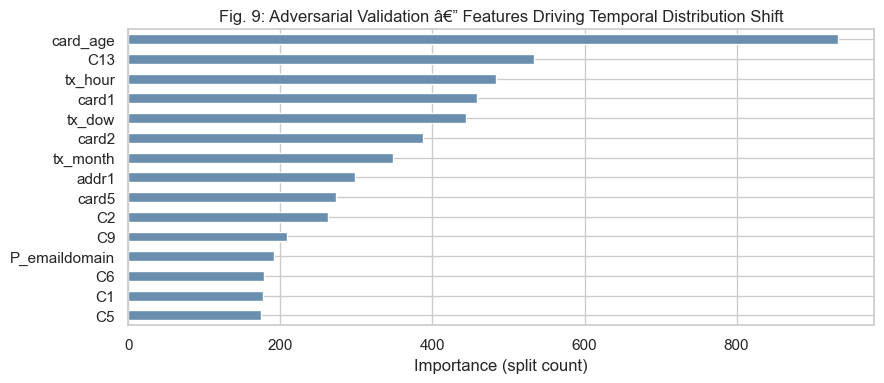

In [13]:
n = len(df)
adv_label = np.where(np.arange(n) >= n//2, 1, 0)

adv_cols = (['card1','card2','card3','card4','card5','card6',
             'addr1','addr2','P_emaildomain','R_emaildomain',
             'tx_hour','tx_dow','tx_month','card_age'] +
            [f'C{i}' for i in range(1,15)])
adv_cols = [c for c in adv_cols if c in df.columns]

adv_X_df = df[adv_cols].copy()
for col in adv_X_df.select_dtypes(include='object').columns:
    adv_X_df[col] = pd.Categorical(adv_X_df[col]).codes
adv_X = adv_X_df.fillna(-999).values

adv_Xtr, adv_Xval, adv_ytr, adv_yval = train_test_split(
    adv_X, adv_label, test_size=0.3, random_state=SEED, stratify=adv_label
)
adv_clf = lgb.LGBMClassifier(n_estimators=200, num_leaves=32,
                              random_state=SEED, n_jobs=-1, verbose=-1)
adv_clf.fit(adv_Xtr, adv_ytr)
adv_auc = roc_auc_score(adv_yval, adv_clf.predict_proba(adv_Xval)[:, 1])

print(f'Adversarial validation AUC: {adv_auc:.4f}')
print('AUC > 0.5 confirms client population shifts over time.')

adv_imp = pd.Series(adv_clf.feature_importances_, index=adv_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
adv_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#6A8EAE')
ax.set_title('Fig. 9: Adversarial Validation -- Features Driving Temporal Distribution Shift')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()